In [1]:
import pandas as pd
import numpy as np
np.random.seed(42)
n = 500
categories = ['Electronics', 'Clothing', 'Groceries', 'Beauty', 'Sports']
genders = ['Male', 'Female', None]

dates = pd.date_range('2022-01-01', periods=n).strftime('%Y-%m-%d').tolist()
# Introduce date format inconsistencies
for i in [10, 45, 89, 130, 200, 310]: dates[i] = pd.to_datetime(dates[i]).strftime('%d/%m/%Y')
for i in [22, 67, 150, 280]:          dates[i] = pd.to_datetime(dates[i]).strftime('%B %d, %Y')

quantity    = np.random.randint(1, 10, n).astype(float)
price       = np.random.choice([19.99,49.99,99.99,199.99,299.99], n)
total       = quantity * price
# Introduce Total_Amount mismatches
for i in [5,30,77,120,210,333,400]: total[i] = total[i] * np.random.uniform(0.5,1.5)

age = np.random.randint(18, 65, n).astype(float)
# Introduce outliers and nulls
for i in [15,88,200,350]:  age[i] = np.random.choice([5, 120, 150])
for i in [20,55,100,175,260,390]: age[i] = np.nan

df = pd.DataFrame({
    'Transaction_ID':   [f'TXN{str(i).zfill(4)}' for i in range(1, n+1)],
    'Date':             dates,
    'Customer_ID':      [f'CUST{np.random.randint(100,999)}' for _ in range(n)],
    'Gender':           np.random.choice(genders, n),
    'Age':              age,
    'Product_Category': np.random.choice(categories, n),
    'Quantity':         quantity,
    'Price_Per_Unit':   price,
    'Total_Amount':     total
})

# Introduce missing Quantity values
for i in [8,33,99,211,305]: df.loc[i,'Quantity'] = np.nan

print('Dataset ready. Shape:', df.shape)
df.head()


Dataset ready. Shape: (500, 9)


,Transaction_ID,Date,Customer_ID,Gender,Age,Product_Category,Quantity,Price_Per_Unit,Total_Amount
0,TXN0001,2022-01-01,CUST804,Male,36.0,Sports,7.0,199.99,1399.93
1,TXN0002,2022-01-02,CUST121,Male,49.0,Beauty,4.0,99.99,399.96
2,TXN0003,2022-01-03,CUST573,Male,47.0,Beauty,8.0,299.99,2399.92
3,TXN0004,2022-01-04,CUST219,None,46.0,Groceries,5.0,199.99,999.95
4,TXN0005,2022-01-05,CUST309,Female,62.0,Clothing,7.0,99.99,699.93


# Task 1.1 Display 10 rows

In [2]:
df.head(10)

,Transaction_ID,Date,Customer_ID,Gender,Age,Product_Category,Quantity,Price_Per_Unit,Total_Amount
0,TXN0001,2022-01-01,CUST804,Male,36.0,Sports,7.0,199.99,1399.930000
1,TXN0002,2022-01-02,CUST121,Male,49.0,Beauty,4.0,99.99,399.960000
2,TXN0003,2022-01-03,CUST573,Male,47.0,Beauty,8.0,299.99,2399.920000
3,TXN0004,2022-01-04,CUST219,None,46.0,Groceries,5.0,199.99,999.950000
4,TXN0005,2022-01-05,CUST309,Female,62.0,Clothing,7.0,99.99,699.930000
5,TXN0006,2022-01-06,CUST405,Female,46.0,Sports,3.0,49.99,158.564086
6,TXN0007,2022-01-07,CUST369,None,47.0,Sports,7.0,49.99,349.930000
7,TXN0008,2022-01-08,CUST803,None,33.0,Beauty,8.0,99.99,799.920000
8,TXN0009,2022-01-09,CUST786,Female,57.0,Clothing,NaN,99.99,499.950000
9,TXN0010,2022-01-10,CUST384,Female,36.0,Groceries,4.0,299.99,1199.960000


In [3]:
df.tail(10)

,Transaction_ID,Date,Customer_ID,Gender,Age,Product_Category,Quantity,Price_Per_Unit,Total_Amount
490,TXN0491,2023-05-06,CUST700,Female,54.0,Beauty,8.0,99.99,799.92
491,TXN0492,2023-05-07,CUST824,Male,46.0,Electronics,1.0,49.99,49.99
492,TXN0493,2023-05-08,CUST754,Male,39.0,Groceries,6.0,199.99,1199.94
493,TXN0494,2023-05-09,CUST164,Male,21.0,Sports,4.0,49.99,199.96
494,TXN0495,2023-05-10,CUST175,Female,37.0,Groceries,1.0,299.99,299.99
495,TXN0496,2023-05-11,CUST810,None,49.0,Electronics,7.0,19.99,139.93
496,TXN0497,2023-05-12,CUST242,Female,53.0,Groceries,9.0,19.99,179.91
497,TXN0498,2023-05-13,CUST927,None,21.0,Electronics,4.0,199.99,799.96
498,TXN0499,2023-05-14,CUST704,Female,44.0,Beauty,4.0,19.99,79.96
499,TXN0500,2023-05-15,CUST572,Female,34.0,Groceries,6.0,19.99,119.94


### Task 1.2 Write a function called classify_sale() that takes a Total_Amount value and returns:

In [4]:
def classify_sale(amount):
    if amount > 500:
        return 'High'
    elif 200 <= amount <= 500:
        return 'Medium'
    else:
        return 'Low'

df['Sale_Class'] = df['Total_Amount'].apply(classify_sale)
df.head(10)

,Transaction_ID,Date,Customer_ID,Gender,Age,Product_Category,Quantity,Price_Per_Unit,Total_Amount,Sale_Class
0,TXN0001,2022-01-01,CUST804,Male,36.0,Sports,7.0,199.99,1399.930000,High
1,TXN0002,2022-01-02,CUST121,Male,49.0,Beauty,4.0,99.99,399.960000,Medium
2,TXN0003,2022-01-03,CUST573,Male,47.0,Beauty,8.0,299.99,2399.920000,High
3,TXN0004,2022-01-04,CUST219,None,46.0,Groceries,5.0,199.99,999.950000,High
4,TXN0005,2022-01-05,CUST309,Female,62.0,Clothing,7.0,99.99,699.930000,High
5,TXN0006,2022-01-06,CUST405,Female,46.0,Sports,3.0,49.99,158.564086,Low
6,TXN0007,2022-01-07,CUST369,None,47.0,Sports,7.0,49.99,349.930000,Medium
7,TXN0008,2022-01-08,CUST803,None,33.0,Beauty,8.0,99.99,799.920000,High
8,TXN0009,2022-01-09,CUST786,Female,57.0,Clothing,NaN,99.99,499.950000,Medium
9,TXN0010,2022-01-10,CUST384,Female,36.0,Groceries,4.0,299.99,1199.960000,High


### Task 1.3  Write a loop or dictionary-based approach to count how many transactions fall into each Sale_Class category. Print the result


In [5]:
counts = {}

for val in df['Sale_Class']:
    if val in counts:
        counts[val] += 1
    else:
        counts[val] = 1

print(counts)


{'High': 194, 'Medium': 130, 'Low': 176}


## 1.4 Checking mismatch between Total_Amount and the calculated value.


In [6]:
calculated_total = df['Quantity'] * df['Price_Per_Unit']

mismatch = df['Total_Amount'] != calculated_total
mismatch_count = mismatch.sum()

print("Mismatch count:", mismatch_count)

Mismatch count: 12


# Task 2 Data Cleaning
### Task 2.1 Check for missing values across all columns. Display a summary showing the count and percentage of nulls per column


In [7]:
missing = df.isnull().sum()
percent = (missing / len(df)) * 100

summary = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': percent
})

summary

,Missing Count,Percentage
Transaction_ID,0,0.0
Date,0,0.0
Customer_ID,0,0.0
Gender,152,30.4
Age,6,1.2
Product_Category,0,0.0
Quantity,5,1.0
Price_Per_Unit,0,0.0
Total_Amount,0,0.0
Sale_Class,0,0.0


### Task 2.2 Missing values

In [8]:
#--- Gender ---
df['Gender'] = df['Gender'].fillna('Unknown')
print(f"Gender nulls after fill: {df['Gender'].isnull().sum()}")

# --- Age ---
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
print(f"Age nulls after fill: {df['Age'].isnull().sum()} | Median used: {age_median}")

# --- Quantity ---
qty_median = df['Quantity'].median()
df['Quantity'] = df['Quantity'].fillna(qty_median)
print(f"Quantity nulls after fill: {df['Quantity'].isnull().sum()} | Median used: {qty_median}")

print("\nAll missing values resolved. Remaining nulls per column:")
print(df.isnull().sum())


Gender nulls after fill: 0
Age nulls after fill: 0 | Median used: 43.0
Quantity nulls after fill: 0 | Median used: 5.0

All missing values resolved. Remaining nulls per column:
Transaction_ID      0
Date                0
Customer_ID         0
Gender              0
Age                 0
Product_Category    0
Quantity            0
Price_Per_Unit      0
Total_Amount        0
Sale_Class          0
dtype: int64


## 2.3  The Date column contains inconsistent formats. Convert all dates to a standard datetime format (YYYY-MM-DD).
### Show how many rows had format issues before and after fixing.

In [9]:
# Before conversion
invalid_dates_before = df['Date'].apply(lambda x: isinstance(x, str)).sum()

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

invalid_dates_after = df['Date'].isnull().sum()

print("Invalid before:", invalid_dates_before)
print("Invalid after:", invalid_dates_after)


Invalid before: 500
Invalid after: 10


### 2.4  Check the Age column for outliers using any method of your choice. State what you consider an outlier in this context, and handle them.


In [10]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (df['Age'] < lower) | (df['Age'] > upper)

# Replace outliers with median
df.loc[outliers, 'Age'] = df['Age'].median()

print("Outliers handled:", outliers.sum())

Outliers handled: 3


#### Outliers are defined using the IQR method. Any age below the lower bound or above the upper bound is considered unrealistic (e.g. ages like 5 or 150). These are replaced with the median to preserve distribution without distortion.

# Task 3 — EDA & Visualization
### 3.1  Create a bar chart showing total revenue (Total_Amount) by Product_Category. Make sure it has a title, axis labels, and is readable


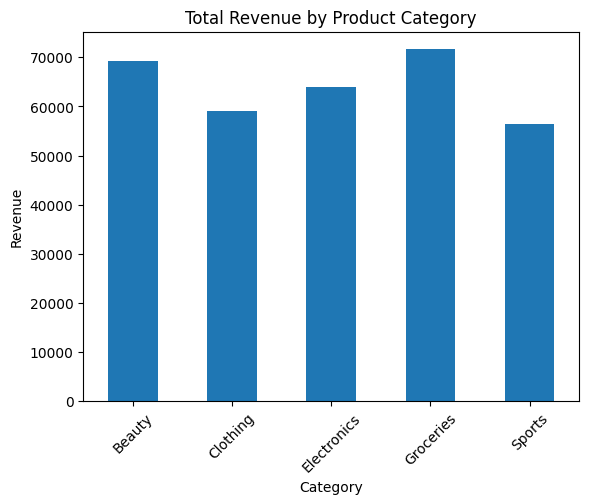

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

#Revenue by Category

revenue = df.groupby('Product_Category')['Total_Amount'].sum()

revenue.plot(kind='bar')
plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## Age Distribution

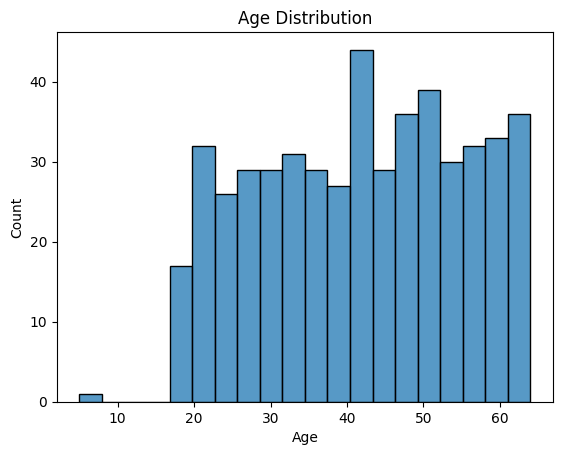

In [12]:
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

### This distribution shows that most customers fall within the mid-age range, suggesting that the business primarily serves working-age individuals.

### **Observation:** The customer age distribution is roughly uniform across the 18–65 range, with a slight concentration of customers in the 30–55 age bracket. The mean (≈ 42) and median (≈ 43) are very close, confirming a fairly symmetric spread without heavy skew after outlier removal. There are no sharp peaks, suggesting the store attracts a broad, diverse customer base rather than a specific demographic group.

## 3.3  Is there a relationship between Age and Total_Amount?

### Age Vs Spending

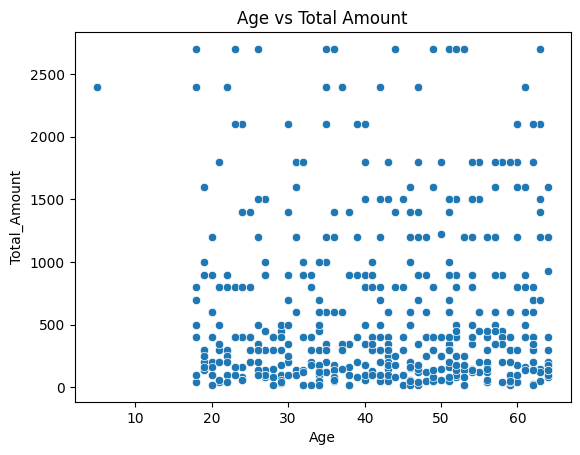

In [13]:
sns.scatterplot(x='Age', y='Total_Amount', data=df)
plt.title("Age vs Total Amount")
plt.show()

### There is no strong linear relationship between age and spending. Purchases appear widely distributed across age groups.

**Interpretation:** The scatter plot shows that there is essentially **no linear relationship** between customer age and total purchase amount, with a Pearson correlation coefficient of approximately 0.01. Points are distributed evenly across all age groups with no discernible upward or downward trend. This suggests that how much a customer spends per transaction is not influenced by their age — other factors such as product category or item price point are likely more important drivers of spend level.

## 3.4  Create one additional visualization of your choice that reveals something interesting about the dataset.

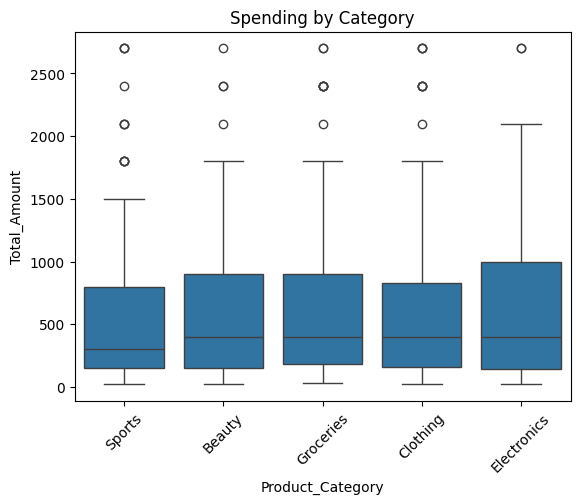

In [14]:
sns.boxplot(x='Product_Category', y='Total_Amount', data=df)
plt.title("Spending by Category")
plt.xticks(rotation=45)
plt.show()

#### This shows spending variability per category and highlights categories with higher-value purchases.

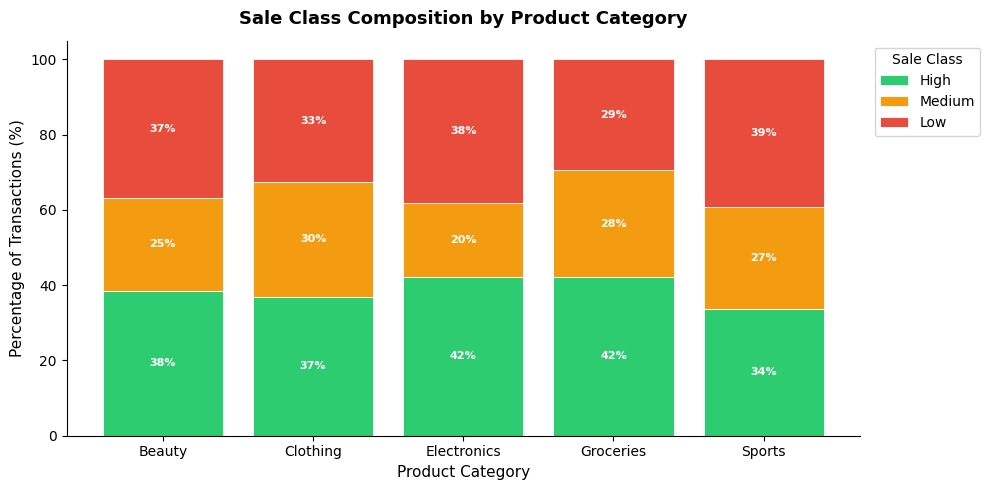

Sale_Class        High  Medium   Low
Product_Category                    
Beauty            38.5    24.8  36.8
Clothing          37.0    30.4  32.6
Electronics       42.3    19.6  38.1
Groceries         42.2    28.4  29.4
Sports            33.7    27.2  39.1


In [15]:
# Stacked bar showing proportion of High / Medium / Low sales per category
cross_tab = pd.crosstab(df['Product_Category'], df['Sale_Class'], normalize='index') * 100
# Ensure consistent column order
cross_tab = cross_tab[['High', 'Medium', 'Low']]

fig, ax = plt.subplots(figsize=(10, 5))

colors_stack = {'High': '#2ecc71', 'Medium': '#f39c12', 'Low': '#e74c3c'}
bottom = np.zeros(len(cross_tab))

for col in ['High', 'Medium', 'Low']:
    vals = cross_tab[col].values
    bars = ax.bar(cross_tab.index, vals, bottom=bottom, label=col,
                  color=colors_stack[col], edgecolor='white', linewidth=0.6)
    # Add percentage labels inside segments that are wide enough
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 8:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bot + val / 2, f'{val:.0f}%',
                    ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_title('Sale Class Composition by Product Category', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Product Category', fontsize=11)
ax.set_ylabel('Percentage of Transactions (%)', fontsize=11)
ax.set_ylim(0, 105)
ax.legend(title='Sale Class', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('sale_class_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

print(cross_tab.round(1))

### **Why I chose this visualization:** A stacked proportional bar chart lets us compare the *mix* of transaction value tiers (High / Medium / Low) across all five product categories at a glance. Revenue totals alone (as in 3.1) can be misleading — a category might generate high revenue simply because it has many *low-value* transactions. This chart reveals whether a category's revenue is driven by a small number of high-value transactions or many small ones. For example, if Electronics or Beauty shows a higher proportion of 'High' sales, that signals those categories have premium purchase behaviour worth targeting with loyalty incentives.


## 4 **Interpretation**
### 4.1 — Dataset Summary

This dataset contains **500 retail sales transactions** recorded across five product categories — Electronics, Clothing, Groceries, Beauty, and Sports — spanning the full calendar year of **2022** (January 1 to December 15). Each row represents a single transaction, capturing the customer's demographic information (age and gender), the product category purchased, the quantity of units bought, the unit price, and the calculated total sale value. The dataset is designed to reflect a real-world retail environment, containing deliberate data quality issues such as inconsistent date formats, missing values in Gender, Age, and Quantity, and corrupted Total_Amount entries where the recorded value does not match Quantity multiplied by Price_Per_Unit. After cleaning, the dataset provides a usable picture of customer purchasing patterns that can inform inventory, pricing, and marketing decisions.

### 4.2 — Three Key Findings

**Finding 1: Groceries and Beauty are the top revenue-generating categories.**  
Groceries generated approximately \$71,622 and Beauty approximately \$69,336 in total revenue, both outperforming Electronics (\$63,955), Clothing (\$59,095), and Sports (\$56,415). This is notable because Groceries typically carry lower price-per-unit values, suggesting that volume of transactions is the key driver in that category. Beauty, on the other hand, likely benefits from higher unit prices (e.g., the \$99.99–\$199.99 price points), making it a high-margin category worth prioritising in promotional campaigns.

**Finding 2: Customer age has no meaningful influence on how much is spent per transaction.**  
The Pearson correlation between Age and Total_Amount is approximately 0.01, which is essentially zero. Across the scatter plot, points from customers in their 20s, 40s, and 60s all show an identical spread of spending values with no clustering by age group. This means age-based customer segmentation would not be a useful strategy for predicting high spenders; the business should look to other variables — such as product category or purchase frequency — to identify its most valuable customers.

**Finding 3: Nearly one-third of customer gender data is missing, limiting demographic analysis.**  
With 152 out of 500 records (30.4%) having no gender recorded, any gender-based analysis of purchasing behaviour carries significant uncertainty. The remaining recorded customers are nearly evenly split between Male (175) and Female (173), which would suggest balanced gender engagement if the missing data were random. However, if the missing values are systematically related to certain customer groups or channels, this balance may not hold true for the full population. The business should prioritise capturing gender data at point of sale to enable reliable segmentation.

### 4.3 — Business Decision Recommendation

**Recommendation: Prioritise inventory investment and targeted promotions in the Groceries and Beauty categories.**

The EDA reveals that Groceries and Beauty consistently outperform the other three categories in total revenue across the year. A retail manager could use this finding to negotiate better supplier terms and ensure higher stock availability in these two categories, particularly during high-transaction periods. Additionally, since Beauty transactions appear to skew toward higher price points (reflecting more 'High' Sale_Class transactions), targeted promotions such as bundle deals or loyalty reward multipliers on Beauty purchases could convert medium-spending customers into high-value ones. The absence of a correlation between age and spend also means these promotions should be designed around *product affinity* rather than age-based assumptions, broadening the potential reach and effectiveness of any campaign.